In [3]:
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import random
import seaborn as sns
import matplotlib

In [ ]:
accs1 = np.load('llama_subtraction_new_accs_100.npy')
accs2 = np.load('llama_subtraction_complement_accs_100.npy')

In [6]:
def top_ten(heatmap, vals=True):
    flat_indices = np.argsort(heatmap, axis=None)[-10:][::-1]
    row_indices, col_indices = np.unravel_index(flat_indices, heatmap.shape)
    top_coords = list(zip(row_indices, col_indices))
    if vals:
        return [(x, round(heatmap[x], 4)) for x in top_coords]
    else:
        return top_coords


def bottom_ten(heatmap, vals=True):
    flat_indices = np.argsort(heatmap, axis=None)[:10]
    row_indices, col_indices = np.unravel_index(flat_indices, heatmap.shape)
    top_coords = list(zip(row_indices, col_indices))
    if vals:
        return [(x, round(heatmap[x], 4)) for x in top_coords]
    else:
        return top_coords

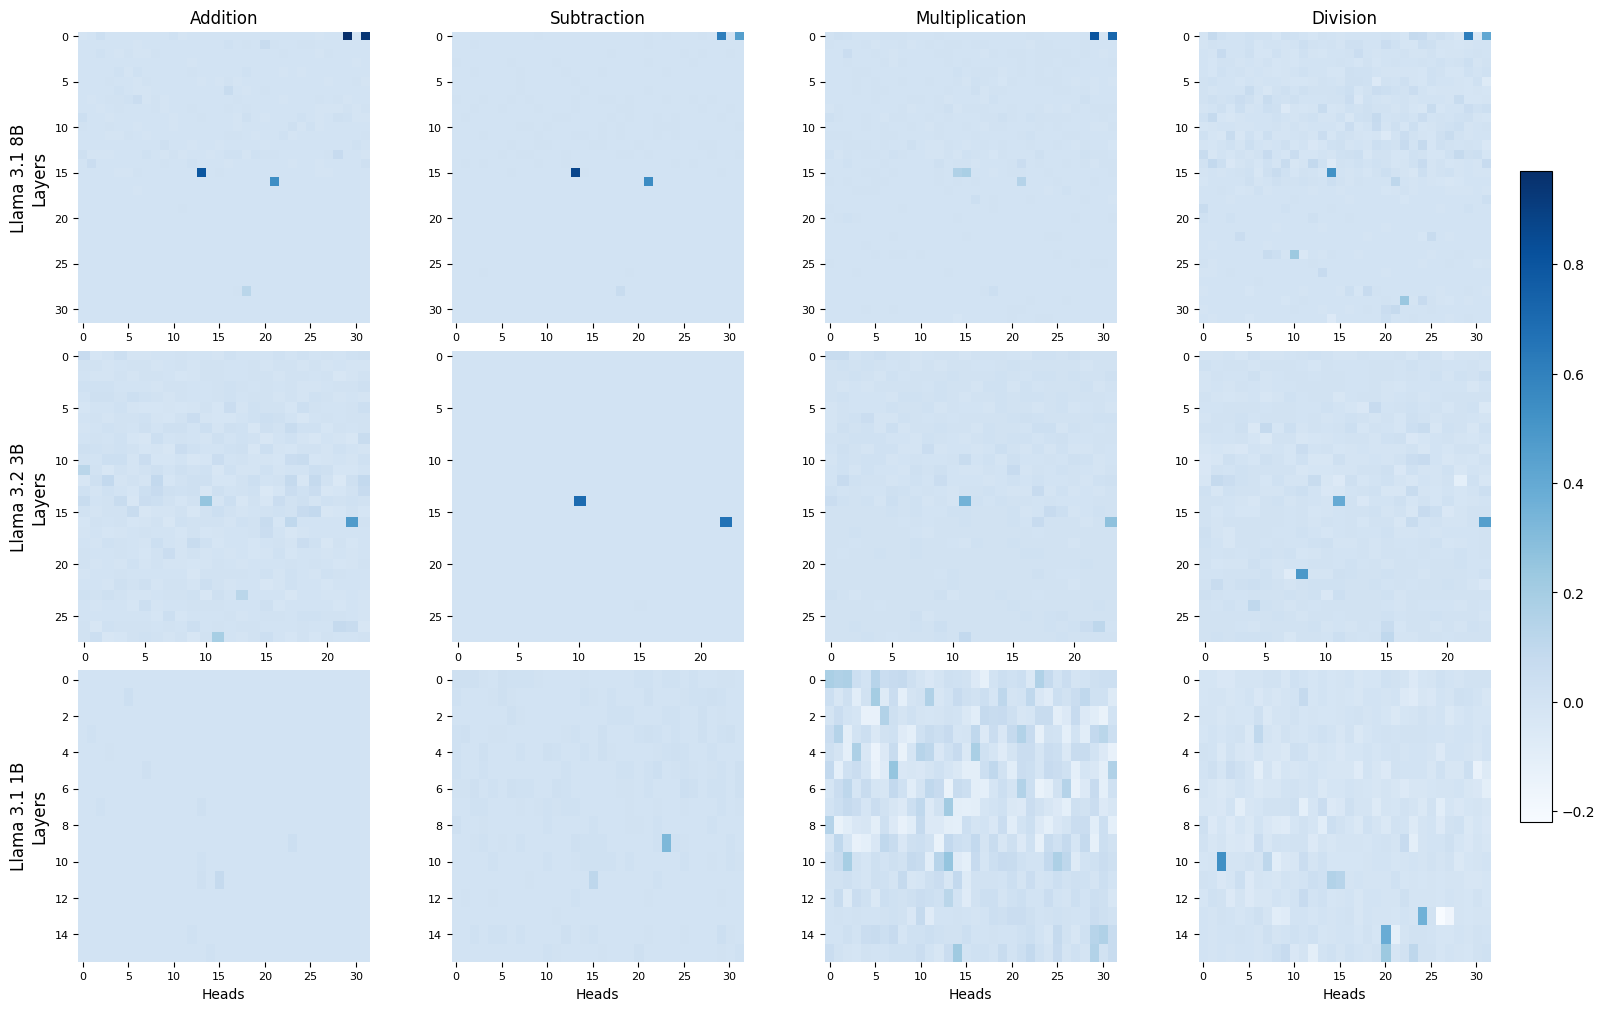

In [148]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Replace with your actual data
plot_data = [
    add_base_1 - add_acc_1, sub_base_1 - sub_acc_1, mul_base_1 - mul_acc_1, div_base_1 - div_acc_1,
    add_base_2 - add_acc_2, sub_base_2 - sub_acc_2, mul_base_2 - mul_acc_2, div_base_2 - div_acc_2,
    add_base_3 - add_acc_3, sub_base_3 - sub_acc_3, mul_base_3 - mul_acc_3, div_base_3 - div_acc_3,
]

titles = ["Addition", "Subtraction", "Multiplication", "Division"]
row_labels = ["Llama 3.1 8B", "Llama 3.2 3B", "Llama 3.1 1B"]

# Compute global color scale
vmin = min(np.nanmin(arr) for arr in plot_data)
vmax = max(np.nanmax(arr) for arr in plot_data)

# Custom colormap
original_cmap = plt.cm.Blues
norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    'truncated_blues',
    original_cmap(norm(np.linspace(vmin, vmax, original_cmap.N))),
    original_cmap.N
)
cmap.set_bad(color='white')

# Grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)

for idx, (ax, data) in enumerate(zip(axes.ravel(), plot_data)):
    row = idx // 4
    col = idx % 4

    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)

    if row == 0:
        ax.set_title(titles[col], fontsize=12)

    if row == 2:
        ax.set_xlabel("Heads", fontsize=10)

    if col == 0:
        ax.set_ylabel(f"{row_labels[row]}\nLayers", fontsize=12)

    ax.set_aspect(data.shape[1] / data.shape[0])
    ax.tick_params(labelsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.7, pad=0.02)
cbar.ax.tick_params(labelsize=10)

plt.savefig("all_models_3x4.pdf")
